> ## **Methodology**
>
> This study applies `yangheng/deberta-v3-base-absa-v1.1` model (ABSA-BERT) to extract aspect-level sentiment scores for five service dimensions:
>
| Aspect | Label passed to model |
|---|---|
| seat | `seat comfort and legroom` |
| food | `food and beverage quality` |
| staff | `cabin crew and customer service` |
| ground_service | `flight delay, baggage, and check-in` |
| entertainment | `inflight entertainment and wifi` |
>
> This model was trained on restaurant/laptop/retail reviews, not airline reviews. **Domain mismatch is an acknowledged limitation**, particularly for ground_service and entertainment.
>

## **1. Environment Setup**

In [4]:
!pip install transformers torch -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


## **2. Mount Google Drive & Load Data**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

# Update this path to match the Google Drive structure
DATA_PATH = '/content/drive/MyDrive/Airline-Review-Sentiment-Classifier/1_data/processed/04_aspect_scores.csv'
OUT_PATH  = '/content/drive/MyDrive/Airline-Review-Sentiment-Classifier/1_data/processed/05_absa_bert_scores.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape}")
df.head(3)

Loaded: (22980, 26)


,Airline Name,Verified,Type Of Traveller,Seat Type,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,...,cleaned_review_C,vader_compound,vader_pos,vader_neg,vader_neu,aspect_seat,aspect_food,aspect_staff,aspect_ground_service,aspect_entertainment
0,AB Aviation,True,Solo Leisure,Economy Class,4.0,5.0,4.0,4.0,NaN,NaN,...,pretty decent airline moroni moheli turned pre...,0.9342,0.217,0.000,0.783,NaN,NaN,NaN,0.9468,NaN
1,AB Aviation,True,Solo Leisure,Economy Class,2.0,2.0,1.0,1.0,NaN,NaN,...,good airline moroni anjouan small airline tick...,-0.8244,0.027,0.091,0.882,NaN,NaN,NaN,0.4215,NaN
2,AB Aviation,True,Solo Leisure,Economy Class,2.0,1.0,1.0,1.0,NaN,NaN,...,flight fortunately short anjouan dzaoudzi smal...,0.7569,0.106,0.027,0.867,NaN,NaN,0.8122,NaN,0.8122


## **3. Load ABSA-BERT Model**

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

MODEL_NAME = 'yangheng/deberta-v3-base-absa-v1.1'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# top_k=None returns all class probabilities (Negative / Neutral / Positive)
absa_classifier = pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    top_k=None,
    device=0 if torch.cuda.is_available() else -1
)

print("Model loaded.")

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model loaded.


## **4. Define Aspect Labels**

In [8]:
# Aspect labels passed to the model as text_pair
# Expanded from single-word keys to fuller phrases to mitigate domain mismatch

ASPECT_LABELS = {
    'seat'            : 'seat comfort and legroom',
    'food'            : 'food and beverage quality',
    'staff'           : 'cabin crew and customer service',
    'ground_service'  : 'flight delay, baggage, and check-in',
    'entertainment'   : 'inflight entertainment and wifi'
}

## **5. Define Scoring Function (Set E1: Full Inference)**

Model output per aspect: `[{label: 'Negative', score: P_neg}, {label: 'Neutral', score: P_neu}, {label: 'Positive', score: P_pos}]`

Weighted score = `P_pos − P_neg` → range −1 to +1, directly comparable to Set C VADER compound scores.

In [9]:
def get_weighted_score(probs: list) -> float:
    """Convert probability list to weighted sentiment score (P_pos - P_neg)."""
    prob_dict = {item['label']: item['score'] for item in probs}
    return round(prob_dict.get('Positive', 0) - prob_dict.get('Negative', 0), 4)


def score_aspects(text: str) -> dict:
    """Return weighted ABSA score for each aspect given a review text."""
    if not isinstance(text, str) or text.strip() == '':
        return {f'absa_{asp}': None for asp in ASPECT_LABELS}

    # Pre-truncate text (BERT's 512 token limit): pipeline auto-truncates anyway, but this is more explicit/predictable
    text = text[:2000]

    results = {}
    for asp, label in ASPECT_LABELS.items():
        try:
            probs = absa_classifier(text, text_pair=label)[0]
            results[f'absa_{asp}'] = get_weighted_score(probs)
        except Exception as e:
            results[f'absa_{asp}'] = None
    return results

# Sanity check
sample = df['cleaned_review_BE'].iloc[0]
print("Sample review:", sample)
print("\nABSA scores:")
print(score_aspects(sample))

Sample review: pretty decent airline. moroni to moheli. turned out to be a pretty decent airline. online booking worked well, checkin and boarding was fine and the plane looked well maintained. its a very short flight just 20 minutes or so so i did not expect much but they still managed to hand our a bottle of water and some biscuits which i though was very nice. both flights on time.

ABSA scores:
{'absa_seat': 0.9722, 'absa_food': 0.9598, 'absa_staff': 0.9679, 'absa_ground_service': 0.9611, 'absa_entertainment': 0.9552}


## **6. Sample Test**

In [10]:
# Test 1 — Entertainment Negative + Rest NOT mentioned
test1 = "The screen was broken and there was no wifi available on this long flight."
print("Test 1:", score_aspects(test1))

# Test 2 — Food Negative + Seat & Staff Positive + Rest NOT mentioned
test2 = "Crew was fantastic and seat was very comfortable. But the food was absolutely terrible, cold and tasteless."
print("Test 2:", score_aspects(test2))

# Test 3 — Ground Service Negative + Rest NOT mentioned
test3 = "Flight was delayed 4 hours with no explanation. Luggage was lost and never recovered."
print("Test 3:", score_aspects(test3))

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Test 1: {'absa_seat': 0.9443, 'absa_food': -0.6027, 'absa_staff': 0.2956, 'absa_ground_service': -0.0532, 'absa_entertainment': -0.9848}
Test 2: {'absa_seat': 0.9967, 'absa_food': -0.9305, 'absa_staff': 0.9625, 'absa_ground_service': -0.2241, 'absa_entertainment': 0.765}
Test 3: {'absa_seat': 0.9382, 'absa_food': -0.8859, 'absa_staff': -0.9478, 'absa_ground_service': -0.9914, 'absa_entertainment': -0.0149}


> ### **Design Rationale for Set E1, E2**
>
> The above sample test shows a systematic pattern where **unmentioned aspects receive inflated or deflated scores** driven by the overall tone of the review.
>
> In Test 1, a review exclusively criticising inflight entertainment returns a seat comfort score of +0.944, a strongly positive signal for an aspect that was never referenced. In Test 3, a review focused solely on ground services produces highly negative scores for food (-0.886) and staff (-0.948), neither of which were mentioned.
>
> This phenomenon occurs because **the ABSA-BERT model is designed to return a sentiment score for a queried aspect by inferring from the overall review context**, regardless of whether that aspect is explicitly mentioned. While this design is intentional and may capture implicit sentiment signals in the domain the model was trained on (restaurant and retail reviews), it introduces **noise in the airline review context, where service dimensions are independent of one another, potentially distorting classifier inputs.** Furthermore, this behaviour is fundamentally different from the rule-based approach in Set C, where unmentioned aspects return `NaN`.
>
> This distinction motivates the construction of two BERT-based feature sets:
>
> - **Set E1 (Full Inference):** ABSA-BERT scores are retained for all five aspects across all reviews, including cases where the aspect is not explicitly mentioned. This allows the model to leverage implicit sentiment signals embedded in the overall review context.
>
> - **Set E2 (Keyword-Gated Inference):** BERT inference is only executed for aspects that are explicitly mentioned in the review, as determined by the same keyword dictionary used in Set C. Unmentioned aspects are assigned `NaN`, consistent with Set C. This ensures that the only difference between Set C and Set E2 is the scoring method (VADER vs BERT), enabling a direct and fair comparison.
>
>
| Comparison | What it reveals |
|---|---|
| Set C vs Set E2 | Effect of scoring method (VADER vs BERT) under identical mention coverage |
| Set C vs Set E1 | Effect of expanding coverage to implicit sentiment via BERT inference |
| Set E1 vs Set E2 | Whether BERT's contextual inference for unmentioned aspects adds or detracts predictive value |
>

## **7. Define Scoring Function (Set E2: Keyword-Gated Inference)**

In [13]:
!pip install vaderSentiment -q

import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

analyzer_test = SentimentIntensityAnalyzer()

# Use the same aspect keywords of Set C
aspect_keywords = {
    'seat': ['seat', 'legroom', 'comfort', 'recline', 'space', 'cushion', 'comfy', 'spacious', 'stretch'],
    'food': ['food', 'meal', 'drink', 'snack', 'beverage', 'dining', 'menu', 'vegetarian'],
    'staff': ['crew', 'staff', 'attendant', 'stewardess', 'service', 'friendly', 'rude', 'attentive'],
    'ground_service': ['delay', 'late', 'on time', 'punctual', 'schedule', 'depart', 'cancel', 'luggage', 'suitcase',
                       'baggage', 'lost', 'checkin', 'check-in', 'refund', 'booking', 'boarding'],
    'entertainment': ['entertainment', 'screen', 'movie', 'ife', 'wifi', 'music']  # ife stands for In-Flight Entertainment
}

def has_aspect_mention(text, keywords):
    """
    Detect whether a given aspect is explicitly mentioned in the review text,
    using the same keyword rules applied in Set C.
    Returns True if any keyword is found in any sentence, False otherwise.
    """
    if pd.isna(text):
        return False
    sentences = sent_tokenize(text)
    return any(
        any(kw in sentence.lower() for kw in keywords)
        for sentence in sentences
    )

def score_aspects_e2(text):
    """
    Run BERT inference only for aspects explicitly mentioned in the review,
    using the same keyword rules applied in Set C.
    Returns None for unmentioned aspects.
    """
    if not isinstance(text, str) or text.strip() == '':
        return {f'absa_{asp}_e2': None for asp in aspect_keywords}

    text = text[:2000]
    results = {}

    for asp, keywords in aspect_keywords.items():
        if has_aspect_mention(text, keywords):
            try:
                probs = absa_classifier(text, text_pair=ASPECT_LABELS[asp])[0]
                results[f'absa_{asp}_e2'] = get_weighted_score(probs)
            except Exception:
                results[f'absa_{asp}_e2'] = None
        else:
            results[f'absa_{asp}_e2'] = None

    return results


# Sanity check
print("=== E1 vs E2 Sanity Check ===\n")

test_reviews = [
    "The screen was broken and there was no wifi available on this long flight.",
    "Crew was fantastic and seat was very comfortable. But the food was absolutely terrible, cold and tasteless.",
    "Flight was delayed 4 hours with no explanation. Luggage was lost and never recovered."
]

for i, review in enumerate(test_reviews, 1):
    print(f"Test {i}: {review[:80]}...")
    e1 = score_aspects(review)
    e2 = score_aspects_e2(review)
    print(f"  E1: {e1}")
    print(f"  E2: {e2}")

=== E1 vs E2 Sanity Check ===

Test 1: The screen was broken and there was no wifi available on this long flight....
  E1: {'absa_seat': 0.9443, 'absa_food': -0.6027, 'absa_staff': 0.2956, 'absa_ground_service': -0.0532, 'absa_entertainment': -0.9848}
  E2: {'absa_seat_e2': None, 'absa_food_e2': None, 'absa_staff_e2': None, 'absa_ground_service_e2': None, 'absa_entertainment_e2': -0.9848}

Test 2: Crew was fantastic and seat was very comfortable. But the food was absolutely te...
  E1: {'absa_seat': 0.9967, 'absa_food': -0.9305, 'absa_staff': 0.9625, 'absa_ground_service': -0.2241, 'absa_entertainment': 0.765}
  E2: {'absa_seat_e2': 0.9967, 'absa_food_e2': -0.9305, 'absa_staff_e2': 0.9625, 'absa_ground_service_e2': None, 'absa_entertainment_e2': None}

Test 3: Flight was delayed 4 hours with no explanation. Luggage was lost and never recov...
  E1: {'absa_seat': 0.9382, 'absa_food': -0.8859, 'absa_staff': -0.9478, 'absa_ground_service': -0.9914, 'absa_entertainment': -0.0149}
  E2: {'a

> ### **E1 vs E2: Identical Scores for Mentioned Aspects**
>
> The E1 and E2 scoring functions use the exact same inputs; same review text, same absa_classifier, same ASPECT_LABELS. So for any aspect where has_aspect_mention() returns `True`, E1 and E2 produce identical scores. The only real difference is that E2 returns `None` for unmentioned aspects, while E1 always forces a score, and the sanity check confirms this.

## **8. Application on Full Dataset**

In [14]:
import os
from tqdm.auto import tqdm

CHECKPOINT_PATH = OUT_PATH.replace('.csv', '_checkpoint.csv')
SAVE_EVERY = 1000

e1_cols = [f'absa_{asp}'    for asp in ASPECT_LABELS]
e2_cols = [f'absa_{asp}_e2' for asp in aspect_keywords]

# Resume from checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    df_done = pd.read_csv(CHECKPOINT_PATH)
    start_idx = len(df_done)
    print(f"Resuming from row {start_idx}")
else:
    df_done = df.copy()
    for col in e1_cols + e2_cols:
        df_done[col] = None
    start_idx = 0
    print("Starting from scratch.")

# Full Inference (E1 + E2 simultaneously)
texts = df['cleaned_review_BE'].tolist()

for i in tqdm(range(start_idx, len(df)), desc='ABSA scoring (E1 + E2)'):
    e1_scores = score_aspects(texts[i])
    e2_scores = score_aspects_e2(texts[i])

    for col, val in e1_scores.items():
        df_done.at[i, col] = val
    for col, val in e2_scores.items():
        df_done.at[i, col] = val

    if (i + 1) % SAVE_EVERY == 0:
        df_done.to_csv(CHECKPOINT_PATH, index=False)
        print(f"  Checkpoint saved at row {i+1}")

print("\nInference complete.")

# Save
df_done.to_csv(OUT_PATH, index=False)
print(f"Saved → {OUT_PATH}")
print(f"Final shape: {df_done.shape}")
df_done.info()

Starting from scratch.


ABSA scoring (E1 + E2):   0%|          | 0/22980 [00:00<?, ?it/s]

  Checkpoint saved at row 1000
  Checkpoint saved at row 2000
  Checkpoint saved at row 3000
  Checkpoint saved at row 4000
  Checkpoint saved at row 5000
  Checkpoint saved at row 6000
  Checkpoint saved at row 7000
  Checkpoint saved at row 8000
  Checkpoint saved at row 9000
  Checkpoint saved at row 10000
  Checkpoint saved at row 11000
  Checkpoint saved at row 12000
  Checkpoint saved at row 13000
  Checkpoint saved at row 14000
  Checkpoint saved at row 15000
  Checkpoint saved at row 16000
  Checkpoint saved at row 17000
  Checkpoint saved at row 18000
  Checkpoint saved at row 19000
  Checkpoint saved at row 20000
  Checkpoint saved at row 21000
  Checkpoint saved at row 22000

Inference complete.
Saved → /content/drive/MyDrive/Airline-Review-Sentiment-Classifier/1_data/processed/05_absa_bert_scores.csv
Final shape: (22980, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22980 entries, 0 to 22979
Data columns (total 36 columns):
 #   Column                  Non-Null Coun

In [22]:
# Data type conversion
for col in e1_cols + e2_cols:
    df_done[col] = pd.to_numeric(df_done[col], errors='coerce')

# Check
print(df_done[e1_cols + e2_cols].dtypes)

# Save
df_done.to_csv(OUT_PATH, index=False)
df_done.info()

absa_seat                 float64
absa_food                 float64
absa_staff                float64
absa_ground_service       float64
absa_entertainment        float64
absa_seat_e2              float64
absa_food_e2              float64
absa_staff_e2             float64
absa_ground_service_e2    float64
absa_entertainment_e2     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22980 entries, 0 to 22979
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airline Name            22980 non-null  object 
 1   Verified                22980 non-null  bool   
 2   Type Of Traveller       22980 non-null  object 
 3   Seat Type               22980 non-null  object 
 4   Seat Comfort            18763 non-null  float64
 5   Cabin Staff Service     18673 non-null  float64
 6   Food & Beverages        14162 non-null  float64
 7   Ground Service          18292 non-null  float64
 8   In

## **9. Output Validation**

In [27]:
# Non-null count comparison
print("=== Non-null counts: Set C vs E1 vs E2 ===")
comparison = pd.DataFrame({
    'Set C' : df_done[['aspect_seat', 'aspect_food', 'aspect_staff',
                        'aspect_ground_service', 'aspect_entertainment']].notna().sum().values,
    'E1'    : df_done[e1_cols].notna().sum().values,
    'E2'    : df_done[e2_cols].notna().sum().values,
}, index=['seat', 'food', 'staff', 'ground_service', 'entertainment'])
print(comparison)

=== Non-null counts: Set C vs E1 vs E2 ===
                Set C     E1     E2
seat             9281  22980   9244
food             8809  22980   8758
staff           16778  22980  16739
ground_service  16542  22980  17336
entertainment    4894  22980   4805


> Logically, Set E2 should yield fewer null values than Set C, given that
> the BERT model always returns a score for any mentioned aspect — unlike
> VADER, which can return `NaN` under certain edge cases. In practice,
> however, Set C produces more non-null values across most aspects.
> This counter-intuitive result is attributable to two factors:
>
> First, the two sets operate on different input texts. Set C applies keyword
> detection on fully preprocessed text (`cleaned_review_C`, with stopword
> removal and lemmatization applied), whereas Set E2 uses minimally preprocessed
> text (`cleaned_review_BE`), consistent with BERT's requirement for full
> sentence context. While both use the same keyword dictionary, the difference
> in text form can affect whether a keyword is successfully matched.
>
> Second, Set E2 truncates input text to 2,000 characters before passing it
> to the BERT model. For longer reviews, keywords appearing beyond this boundary
> are not detected, resulting in `NaN` for the corresponding aspect — a limitation
> that does not apply to Set C.
>
> These discrepancies are minor (< 4% across all aspects) and are not expected
> to materially affect downstream classification results.

In [30]:
# Score Distribution Check
print("\n=== Score Distribution: E1 ===")
print(df_done[e1_cols].describe().round(3))

print("\n=== Score Distribution: E2 ===")
print(df_done[e2_cols].describe().round(3))


=== Score Distribution: E1 ===
       absa_seat  absa_food  absa_staff  absa_ground_service  \
count  22980.000  22980.000   22980.000            22980.000   
mean      -0.158     -0.275      -0.271               -0.348   
std        0.817      0.832       0.864                0.774   
min       -0.995     -0.995      -0.996               -0.996   
25%       -0.891     -0.948      -0.966               -0.950   
50%       -0.622     -0.836      -0.882               -0.853   
75%        0.914      0.849       0.918                0.533   
max        0.998      0.998       0.998                0.996   

       absa_entertainment  
count           22980.000  
mean               -0.252  
std                 0.807  
min                -0.996  
25%                -0.925  
50%                -0.764  
75%                 0.809  
max                 0.998  

=== Score Distribution: E2 ===
       absa_seat_e2  absa_food_e2  absa_staff_e2  absa_ground_service_e2  \
count      9244.000      8758.0

### Score Distribution Analysis: E1 vs E2

#### Mean vs Median
Mean is sensitive to extreme values. In Set E1, unmentioned aspects tend to
receive extreme scores (close to ±1.0) driven by overall review sentiment
(sentiment bleeding), which pulls the mean toward the dominant tone of the
dataset. Median, being resistant to such outliers, better represents the
typical score of a review and is therefore a more reliable basis for
comparing E1 and E2.

#### Median Comparison

| Aspect | E1 median | E2 median | Difference | Interpretation |
|---|---|---|---|---|
| seat | -0.622 | +0.134 | 0.756 | E1 heavily skewed negative |
| food | -0.836 | +0.421 | 1.257 | E1 most severely distorted |
| staff | -0.882 | -0.780 | 0.102 | Relatively consistent |
| ground_service | -0.853 | -0.881 | 0.028 | Nearly identical ✅ |
| entertainment | -0.764 | -0.499 | 0.265 | E1 moderately skewed |

#### Key Insight
The degree of distortion in E1 is inversely proportional to the mention rate
of each aspect:

- **Low mention rate** (seat ~40%, food ~38%, entertainment ~21%): Large median
gap between E1 and E2, indicating severe sentiment bleeding into unmentioned aspects.
- **High mention rate** (staff ~73%, ground_service ~72%): Minimal median gap,
as the majority of E1 scores are based on actual mentions.

This confirms that Set E1's negative bias is not a reflection of true aspect-level
sentiment, but an artefact of the model inferring from overall review tone for
unmentioned aspects. Set E2, by restricting scoring to explicitly mentioned aspects,
provides a more reliable signal for downstream classification.

---

### 점수 분포 분석: E1 vs E2

#### 평균 vs 중앙값
평균은 극단값에 민감해. Set E1에서 언급되지 않은 aspect들은 전체 리뷰 감정에
끌려가 ±1.0에 가까운 극단값을 가지는 경향이 있어(sentiment bleeding). 이로 인해
평균이 데이터셋의 지배적인 감정 방향으로 왜곡돼. 반면 중앙값은 이런 극단값의
영향을 받지 않아서 "전형적인 리뷰의 점수"를 더 정확하게 반영하므로, E1과 E2를
비교할 때 더 신뢰할 수 있는 기준이 돼.

#### 중앙값 비교

| Aspect | E1 중앙값 | E2 중앙값 | 차이 | 해석 |
|---|---|---|---|---|
| seat | -0.622 | +0.134 | 0.756 | E1이 부정 방향으로 심하게 왜곡 |
| food | -0.836 | +0.421 | 1.257 | E1 왜곡이 가장 심함 |
| staff | -0.882 | -0.780 | 0.102 | 비교적 일관적 |
| ground_service | -0.853 | -0.881 | 0.028 | 거의 동일 ✅ |
| entertainment | -0.764 | -0.499 | 0.265 | E1이 중간 수준으로 왜곡 |

#### 핵심 인사이트
E1의 왜곡 정도는 각 aspect의 언급 비율에 반비례해:

- **낮은 언급 비율** (seat ~40%, food ~38%, entertainment ~21%): E1과 E2의
중앙값 차이가 크고, sentiment bleeding이 심함.
- **높은 언급 비율** (staff ~73%, ground_service ~72%): 중앙값 차이가 작고,
E1 점수의 대부분이 실제 언급에 기반하기 때문.

이는 E1의 부정 편향이 실제 aspect별 감정을 반영하는 게 아니라, 모델이 언급되지
않은 aspect에 대해 전체 리뷰 감정으로 추론하는 것의 부산물임을 확인해줘.
Set E2는 명시적으로 언급된 aspect에만 점수를 산출함으로써 분류 모델에 더
신뢰할 수 있는 신호를 제공해.

## **10. Correlation Analysis**

Set B vs E1 (document-level): r = 0.784
Set C vs E2 (seat                ): r = 0.690
Set C vs E2 (food                ): r = 0.692
Set C vs E2 (staff               ): r = 0.734
Set C vs E2 (ground_service      ): r = 0.662
Set C vs E2 (entertainment       ): r = 0.660


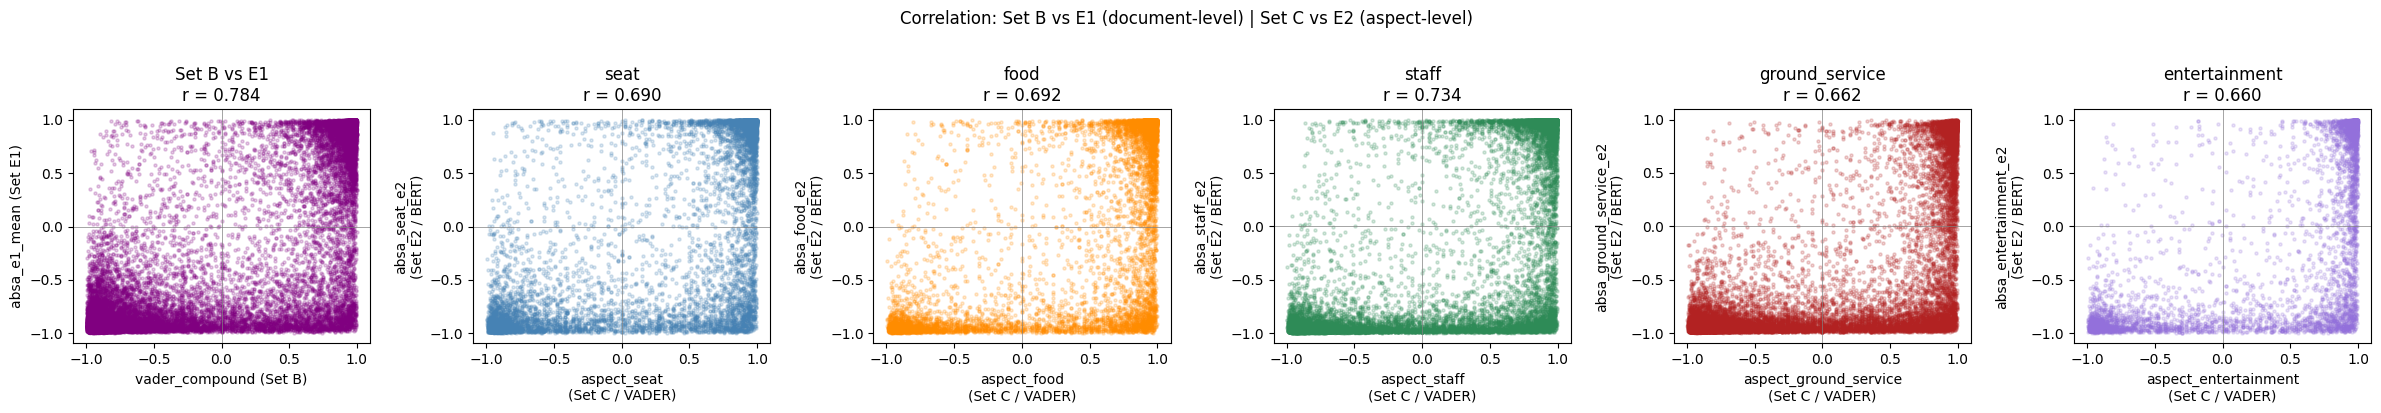

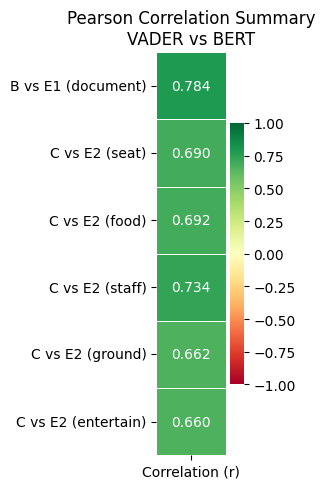

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 1. vader_compound vs absa_e1_mean ──
df_done['absa_e1_mean'] = df_done[e1_cols].mean(axis=1)

corr_b_e1 = df_done[['vader_compound', 'absa_e1_mean']].corr().iloc[0, 1]
print(f"Set B vs E1 (document-level): r = {corr_b_e1:.3f}")

# ── 2. Set C vs E2 aspect-level ──
aspects = ['seat', 'food', 'staff', 'ground_service', 'entertainment']
corr_c_e2 = {}
for asp in aspects:
    pair = df_done[[f'aspect_{asp}', f'absa_{asp}_e2']].dropna()
    corr_c_e2[asp] = pair.corr().iloc[0, 1]
    print(f"Set C vs E2 ({asp:<20}): r = {corr_c_e2[asp]:.3f}")

# ────────────────────────────────────────
# Scatter Plots
# ────────────────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(24, 4))

# Plot 1 — Set B vs E1 (document-level)
axes[0].scatter(
    df_done['vader_compound'],
    df_done['absa_e1_mean'],
    alpha=0.2, s=5, color='purple'
)
axes[0].set_xlabel('vader_compound (Set B)')
axes[0].set_ylabel('absa_e1_mean (Set E1)')
axes[0].set_title(f'Set B vs E1\nr = {corr_b_e1:.3f}')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)

# Plots 2-6 — Set C vs E2 (aspect-level)
colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick', 'mediumpurple']
for j, (asp, color) in enumerate(zip(aspects, colors)):
    pair = df_done[[f'aspect_{asp}', f'absa_{asp}_e2']].dropna()
    axes[j+1].scatter(
        pair[f'aspect_{asp}'],
        pair[f'absa_{asp}_e2'],
        alpha=0.2, s=5, color=color
    )
    axes[j+1].set_xlabel(f'aspect_{asp}\n(Set C / VADER)')
    axes[j+1].set_ylabel(f'absa_{asp}_e2\n(Set E2 / BERT)')
    axes[j+1].set_title(f'{asp}\nr = {corr_c_e2[asp]:.3f}')
    axes[j+1].axhline(0, color='gray', linewidth=0.5)
    axes[j+1].axvline(0, color='gray', linewidth=0.5)

plt.suptitle('Correlation: Set B vs E1 (document-level) | Set C vs E2 (aspect-level)', y=1.02)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# Heatmap
# ────────────────────────────────────────
corr_summary = pd.DataFrame({
    'Correlation (r)': {
        'B vs E1 (document)' : corr_b_e1,
        'C vs E2 (seat)'     : corr_c_e2['seat'],
        'C vs E2 (food)'     : corr_c_e2['food'],
        'C vs E2 (staff)'    : corr_c_e2['staff'],
        'C vs E2 (ground)'   : corr_c_e2['ground_service'],
        'C vs E2 (entertain)': corr_c_e2['entertainment'],
    }
})

plt.figure(figsize=(3, 5))
sns.heatmap(
    corr_summary,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, cbar=True
)
plt.title('Pearson Correlation Summary\nVADER vs BERT')
plt.tight_layout()
plt.show()

전체 패턴
모든 correlation이 0.66~0.78 범위야. 이건 중간~강한 양의 상관관계로, VADER랑 BERT가 감정 방향은 대체로 일치하지만 완전히 같지는 않다는 뜻이야.

Set B vs E1: r = 0.784 (가장 높음)
문서 레벨에서 VADER compound랑 BERT 평균 점수가 가장 잘 일치해. 이건 자연스러운 결과야 — 둘 다 리뷰 전체를 보고 감정을 판단하니까.

Set C vs E2: r = 0.660~0.734
aspect 레벨로 내려오면 correlation이 낮아져. 이건 두 가지 이유야:
방법론 차이:
Set C는 키워드 있는 문장만 잘라서 VADER 적용
E2는 리뷰 전체 문맥을 보고 BERT 추론
판단 근거가 된 텍스트 범위가 달라서 점수가 달라지는 거야

aspect별 패턴:

staff r = 0.734 — 가장 높음. staff 관련 표현이 명확해서 두 방법론이 잘 일치
entertainment r = 0.660, ground_service r = 0.662 — 가장 낮음. 항공 특화 맥락이라 domain mismatch 영향이 큰 거야

> ### **Correlation Analysis: VADER vs BERT Scoring Methods**
>
> To assess the degree of agreement between VADER-based and BERT-based scoring,
> Pearson correlation coefficients were computed at two levels of granularity:
>
> - **Document-level**: `vader_compound` (Set B) vs mean of five ABSA-BERT scores (Set E1)
> - **Aspect-level**: Rule-based VADER aspect scores (Set C) vs Keyword-Gated BERT scores (Set E2)
>
> | Comparison | r |
> |---|---|
> | Set B vs E1 (document-level) | 0.784 |
> | Set C vs E2 (seat) | 0.690 |
> | Set C vs E2 (food) | 0.692 |
> | Set C vs E2 (staff) | 0.734 |
> | Set C vs E2 (ground_service) | 0.662 |
> | Set C vs E2 (entertainment) | 0.660 |
>
> #### Interpretation
>
> All correlations fall in the moderate-to-strong range (r = 0.66–0.78),
> indicating that VADER and BERT capture sentiment in broadly the same direction,
> but are not interchangeable.
>
> **Document-level (r = 0.784)** yields the highest correlation, which is
> expected — both `vader_compound` and `absa_e1_mean` evaluate the overall
> tone of the review as a whole, making them the most directly comparable.
>
> **Aspect-level correlations (r = 0.660–0.734)** are consistently lower,
> reflecting two sources of divergence:
>
> - *Text scope*: Set C scores aspect-matched sentence fragments, while Set E2
> conditions on the full review text. Even for the same aspect in the same review,
> the two methods draw on different portions of the text.
>
> - *Domain mismatch*: `entertainment` (r = 0.660) and `ground_service` (r = 0.662)
> show the weakest agreement — both are airline-specific dimensions that are
> underrepresented in the restaurant and retail data the BERT model was trained on,
> likely causing greater divergence from VADER's keyword-based scores.
>
> - *Aspect clarity*: `staff` (r = 0.734) shows the strongest aspect-level
> agreement, suggesting that staff-related sentiment is expressed in sufficiently
> universal language for both methods to converge.
>
> These correlation values confirm that VADER and BERT capture overlapping but
> distinct signals. The divergence between the two methods — particularly at the
> aspect level — motivates their separate inclusion as feature sets in the
> ablation study, as they may contribute differently to downstream classification
> performance.